In [ ]:
import random
import os

# -----------------------------
# Example usage with comprehensive inputs for fashion_advisor
# -----------------------------
user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
user_example_brand = "Zara" # User usually wears this brand
target_example_brand = "H&M" # User wants to buy from this brand
item_example_condition = "Like-New" # Condition of the item for resale estimation

valid_image_path = None
# Directly try to find an image in the populated fashion_data directory for robust testing
fashion_data_root = "/content/fashion_data"
if os.path.exists(fashion_data_root) and os.listdir(fashion_data_root):
    all_image_files = []
    for root, _, files in os.walk(fashion_data_root):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_image_files.append(os.path.join(root, file))
    if all_image_files:
        valid_image_path = random.choice(all_image_files)

if valid_image_path:
    print(f"Using example image: {valid_image_path}")
    result = fashion_advisor(
        valid_image_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT:")
    print(result)
else:
    print("Error: No valid image paths found for the example. Please ensure:")
    print(f"1. The data preparation cells (like populating {fashion_data_root}) have been run.")
    print(f"2. The directory '{fashion_data_root}' exists and contains image files.")
    if not os.path.exists(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' does NOT exist.")
    elif not os.listdir(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' is EMPTY.")
    else:
        print(f"   - Directory '{fashion_data_root}' exists and contains: {os.listdir(fashion_data_root)[:5]}...")

Error: No valid image paths found for the example. Please ensure:
1. The data preparation cells (like populating /content/fashion_data) have been run.
2. The directory '/content/fashion_data' exists and contains image files.
   - Directory '/content/fashion_data' does NOT exist.


In [ ]:
import random
import os

# -----------------------------
# Example usage with comprehensive inputs for fashion_advisor
# -----------------------------
user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
user_example_brand = "Zara" # User usually wears this brand
target_example_brand = "H&M" # User wants to buy from this brand
item_example_condition = "Like-New" # Condition of the item for resale estimation

valid_image_path = None
# Directly try to find an image in the populated fashion_data directory for robust testing
fashion_data_root = "/content/fashion_data"
if os.path.exists(fashion_data_root) and os.listdir(fashion_data_root):
    all_image_files = []
    for root, _, files in os.walk(fashion_data_root):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_image_files.append(os.path.join(root, file))
    if all_image_files:
        valid_image_path = random.choice(all_image_files)

if valid_image_path:
    print(f"Using example image: {valid_image_path}")
    result = fashion_advisor(
        valid_image_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT:")
    print(result)
else:
    print("Error: No valid image paths found for the example. Please ensure:")
    print(f"1. The data preparation cells (like populating {fashion_data_root}) have been run.")
    print(f"2. The directory '{fashion_data_root}' exists and contains image files.")
    if not os.path.exists(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' does NOT exist.")
    elif not os.listdir(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' is EMPTY.")
    else:
        print(f"   - Directory '{fashion_data_root}' exists and contains: {os.listdir(fashion_data_root)[:5]}...")

Error: No valid image paths found for the example. Please ensure:
1. The data preparation cells (like populating /content/fashion_data) have been run.
2. The directory '/content/fashion_data' exists and contains image files.
   - Directory '/content/fashion_data' does NOT exist.


In [ ]:
# 2. AI Fair Resale Value Estimator
baseline_retail_prices = {
    "Luxury": {
        "Gucci": {
            "shirt": 700,
            "jeans": 800,
            "dresses": 2500,
            "leather jacket": 4500,
            "handbags": 3000,
            "tshirts": 400
        }
    },
    "Mid-Range": {
        "Zara": {
            "shirt": 50,
            "jeans": 60,
            "dresses": 80,
            "leather jacket": 150,
            "tshirts": 30
        },
        "H&M": {
            "shirt": 30,
            "jeans": 40,
            "dresses": 60,
            "tshirts": 20
        }
    }
}

def estimate_resale_value(brand, category, condition):
    brand_lower = brand.lower().replace(" ", "").replace("-", "")
    category_lower = category.lower().replace(" ", "").replace("-", "")

    base_price = 0
    brand_tier = "Unknown"

    # Find base price and tier
    for tier, brands_in_tier in baseline_retail_prices.items():
        for b, items in brands_in_tier.items():
            if b.lower().replace(" ", "").replace("-", "") == brand_lower:
                brand_tier = tier
                if category_lower in [c.lower().replace(" ", "").replace("-", "") for c in items]:
                    # Normalize category key for lookup
                    category_key = next((c for c in items if c.lower().replace(" ", "").replace("-", "") == category_lower), category)
                    base_price = items[category_key]
                break
        if base_price > 0: # Found the brand and category
            break

    if base_price == 0:
        return f"Resale value estimation not available for {brand} {category}."

    # Depreciation multipliers
    depreciation_multipliers = {
        "Like-New": 0.8,
        "Good": 0.6,
        "Fair": 0.4,
        "Poor": 0.2
    }

    condition_multiplier = depreciation_multipliers.get(condition, 0.3) # Default to a conservative multiplier

    # Category-specific adjustments (e.g., leather jackets hold value better)
    category_adjustment = 1.0
    if "leather" in category_lower and "jacket" in category_lower:
        category_adjustment = 1.2
    elif "handbags" in category_lower:
        category_adjustment = 1.1
    elif "tshirt" in category_lower or "shirt" in category_lower:
        category_adjustment = 0.9

    estimated_value = base_price * condition_multiplier * category_adjustment

    # Generate a price range for realism (e.g., +/- 10%)
    min_price = estimated_value * 0.9
    max_price = estimated_value * 1.1

    return f"Estimated resale value for a {condition} {brand} {category}: ${min_price:.2f} - ${max_price:.2f} (Tier: {brand_tier})"

In [ ]:
brand_size_data = {
    "Zara": {
        "shirt": [
            {"size": "S", "chest": 96, "waist": 84, "tier": "Fast Fashion"},
            {"size": "M", "chest": 100, "waist": 88, "tier": "Fast Fashion"},
            {"size": "L", "chest": 104, "waist": 92, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 108, "waist": 96, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "28", "waist": 71, "hip": 89, "tier": "Fast Fashion"},
            {"size": "30", "waist": 76, "hip": 94, "tier": "Fast Fashion"},
            {"size": "32", "waist": 81, "hip": 99, "tier": "Fast Fashion"},
        ],
        "dresses": [
            {"size": "S", "bust": 84, "waist": 68, "hip": 92, "tier": "Fast Fashion"},
            {"size": "M", "bust": 88, "waist": 72, "hip": 96, "tier": "Fast Fashion"},
            {"size": "L", "bust": 92, "waist": 76, "hip": 100, "tier": "Fast Fashion"},
        ]
    },
    "H&M": {
        "shirt": [
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "29", "waist": 74, "hip": 92, "tier": "Fast Fashion"},
            {"size": "31", "waist": 79, "hip": 97, "tier": "Fast Fashion"},
            {"size": "33", "waist": 84, "hip": 102, "tier": "Fast Fashion"},
        ],
         "dresses": [
            {"size": "S", "bust": 86, "waist": 70, "hip": 94, "tier": "Fast Fashion"},
            {"size": "M", "bust": 90, "waist": 74, "hip": 98, "tier": "Fast Fashion"},
            {"size": "L", "bust": 94, "waist": 78, "hip": 102, "tier": "Fast Fashion"},
        ]
    },
    "Levi's": {
        "jeans": [
            {"size": "28", "waist": 72, "hip": 90, "tier": "Premium"},
            {"size": "30", "waist": 77, "hip": 95, "tier": "Premium"},
            {"size": "32", "waist": 82, "hip": 100, "tier": "Premium"},
            {"size": "34", "waist": 87, "hip": 105, "tier": "Premium"},
        ],
        "shirt": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Premium"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Premium"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Premium"},
        ]
    },
    "Gucci": {
        "shirt": [
            {"size": "48IT", "chest": 92, "waist": 80, "tier": "Luxury"},
            {"size": "50IT", "chest": 96, "waist": 84, "tier": "Luxury"},
            {"size": "52IT", "chest": 100, "waist": 88, "tier": "Luxury"},
        ],
        "leather jacket": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Luxury"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Luxury"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Luxury"},
        ],
        "handbags": [
            {"size": "One Size", "dimensions": "30x20x10cm", "tier": "Luxury"}
        ]
    }
}

# Define categories where size recommendation is applicable, normalized for lookup
size_categories = ["shirt", "tshirts", "jeans", "dresses", "jackets", "leather jacket", "sweaters", "sweatshirts", "hoodies", "trousers", "shorts"]

def translate_size(user_measurements, target_brand, category):
    category_lower = category.lower().replace(" ", "").replace("-", "")
    target_brand_norm = target_brand.lower().replace(" ", "").replace("-", "")

    target_brand_key = next((k for k in brand_size_data if k.lower().replace(" ", "").replace("-", "") == target_brand_norm), None)

    if not target_brand_key or category_lower not in [k.lower().replace(" ", "").replace("-", "") for k in brand_size_data[target_brand_key]]:
        return f"Size data not available for target brand '{target_brand}' or category '{category}'."

    category_key_target = next((k for k in brand_size_data[target_brand_key] if k.lower().replace(" ", "").replace("-", "") == category_lower), None)

    best_target_size = None
    min_diff_score = float('inf')

    for target_item in brand_size_data[target_brand_key][category_key_target]:
        current_diff_score = 0

        measurement_keys = ["chest", "waist", "bust", "hip"]
        for key in measurement_keys:
            if key in user_measurements and key in target_item:
                current_diff_score += abs(user_measurements[key] - target_item[key]) * 2 # Chest/bust more critical
            elif key in user_measurements or key in target_item:
                current_diff_score += 10 # Penalize missing measurements

        if "dimensions" in user_measurements and "dimensions" in target_item:
            if user_measurements["dimensions"] == target_item["dimensions"]:
                current_diff_score = 0
            else:
                current_diff_score += 50
        elif "dimensions" in user_measurements or "dimensions" in target_item:
             current_diff_score += 25

        if current_diff_score < min_diff_score:
            min_diff_score = current_diff_score
            best_target_size = target_item["size"]

    return best_target_size if best_target_size else f"Could not find a suitable size in '{target_brand_key}' for '{category_key_target}'."

In [6]:
import pandas as pd
import os
import shutil
from tqdm import tqdm

# --- Clean up any previous conflicting data --- START
# Remove any top-level 'styles.csv' or 'images' that might interfere
if os.path.exists('styles.csv') and os.path.isfile('styles.csv'):
    os.remove('styles.csv')
if os.path.exists('images') and os.path.isdir('images'):
    shutil.rmtree('images')

# Remove existing 'myntradataset' to ensure a fresh unzip
if os.path.exists('myntradataset') and os.path.isdir('myntradataset'):
    shutil.rmtree('myntradataset')

# Remove existing 'fashion_data' as it will be recreated
if os.path.exists('/content/fashion_data') and os.path.isdir('/content/fashion_data'):
    shutil.rmtree('/content/fashion_data')
# --- Clean up --- END

# Re-download and Re-unzip the dataset to ensure correct structure
!kaggle datasets download -d paramaggarwal/fashion-product-images-small
!unzip -o fashion-product-images-small.zip

# ✅ Correct paths based on the standard Kaggle dataset structure after fresh unzip
df = pd.read_csv("myntradataset/styles.csv", on_bad_lines='skip')

image_dir = "myntradataset/images"
output_dir = "/content/fashion_data"

os.makedirs(output_dir, exist_ok=True)

# 🔥 (optional) take subset for faster training
# df = df.sample(5000) # Removed sampling to ensure full dataset is processed

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_id = str(row["id"]) + ".jpg"
    category = str(row["articleType"])

    src = os.path.join(image_dir, img_id)
    dest_folder = os.path.join(output_dir, category)

    if os.path.exists(src):
        os.makedirs(dest_folder, exist_ok=True)
        shutil.copy(src, os.path.join(dest_folder, img_id))

Streaming output truncated to the last 5000 lines.
  inflating: myntradataset/images/58131.jpg  
  inflating: myntradataset/images/58132.jpg  
  inflating: myntradataset/images/58133.jpg  
  inflating: myntradataset/images/58135.jpg  
  inflating: myntradataset/images/58136.jpg  
  inflating: myntradataset/images/58137.jpg  
  inflating: myntradataset/images/58138.jpg  
  inflating: myntradataset/images/58139.jpg  
  inflating: myntradataset/images/5814.jpg  
  inflating: myntradataset/images/58140.jpg  
  inflating: myntradataset/images/58141.jpg  
  inflating: myntradataset/images/58143.jpg  
  inflating: myntradataset/images/58144.jpg  
  inflating: myntradataset/images/58145.jpg  
  inflating: myntradataset/images/58146.jpg  
  inflating: myntradataset/images/58147.jpg  
  inflating: myntradataset/images/58148.jpg  
  inflating: myntradataset/images/58149.jpg  
  inflating: myntradataset/images/5815.jpg  
  inflating: myntradataset/images/58150.jpg  
  inflating: myntradataset/imag

100%|██████████| 44424/44424 [00:13<00:00, 3334.15it/s]


In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch

# Use robust data augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    # CRITICAL: ImageNet stats for ResNet
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder("/content/fashion_data", transform=transform)

# --- NEW: Fix Class Imbalance using WeightedSampler ---
class_counts = [0] * len(dataset.classes)
for _, label in dataset.samples:
    class_counts[label] += 1

# Calculate the weight for each sample
weights = [1.0 / count if count > 0 else 0 for count in class_counts]
sample_weights = [weights[label] for _, label in dataset.samples]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(dataset),
    replacement=True
)

# Use the sampler INSTEAD of shuffle=True
loader = DataLoader(dataset, batch_size=32, sampler=sampler)

In [8]:
import pickle
import os # Import os module to create directories

classes = dataset.classes

print("Total classes:", len(classes))

# Ensure the directory exists before saving
os.makedirs('/content/drive/MyDrive/fashion_ai', exist_ok=True)

with open("/content/drive/MyDrive/fashion_ai/classes.pkl", "wb") as f:
    pickle.dump(classes, f)

print("✅ classes.pkl saved")

Total classes: 142
✅ classes.pkl saved


In [9]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights # Import specific weights

# Use CUDA if available, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

num_classes = len(dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

print(f"Attempting to move model to device: {device} with {num_classes} output classes.")
model = model.to(device)
print("Model successfully moved to device.")

Attempting to move model to device: cuda with 142 output classes.
Model successfully moved to device.


In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()

# Lowering from 0.001 to 0.0001 prevents the pre-trained weights from being destroyed
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Automatically lowers LR if the loss stops decreasing
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)


In [11]:
from tqdm import tqdm
import torch

epochs = 20

print(f"Training loop starting. Current device: {device}")
print(f"Is torch.cuda.is_available(): {torch.cuda.is_available()}")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

    # Step the scheduler at the end of the epoch
    scheduler.step(avg_loss)


Training loop starting. Current device: cuda
Is torch.cuda.is_available(): True


100%|██████████| 1389/1389 [04:55<00:00,  4.71it/s]


Epoch 1, Avg Loss: 0.8129


100%|██████████| 1389/1389 [04:56<00:00,  4.69it/s]


Epoch 2, Avg Loss: 0.1951


...

Epoch 18, Avg Loss: 0.0479


100%|██████████| 1389/1389 [04:51<00:00,  4.77it/s]


Epoch 19, Avg Loss: 0.0456


100%|██████████| 1389/1389 [04:52<00:00,  4.75it/s]

Epoch 20, Avg Loss: 0.0479


In [13]:
print("Installing faiss-cpu...")
!pip install faiss-cpu
print("faiss-cpu installed.")

Installing faiss-cpu...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 53.1 MB/s eta 0:00:00
faiss-cpu installed.


In [14]:
import faiss
import pickle
import torch
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

base_path = "/content/drive/MyDrive/fashion_ai"
os.makedirs(base_path, exist_ok=True)

# Save FAISS index
if 'index' in globals() and index is not None and index.ntotal > 0: # Ensure index is not empty
    faiss.write_index(index, f"{base_path}/faiss.index")
    print("✅ FAISS index saved")
else:
    print("FAISS index not found or empty, skipping save.")

# Save image paths
if 'image_paths' in globals() and image_paths is not None:
    with open(f"{base_path}/image_paths.pkl", "wb") as f:
        pickle.dump(image_paths, f)
    print("✅ image_paths.pkl saved")
else:
    print("image_paths not found, skipping save.")

# Save classes
if 'classes' in globals() and classes is not None:
    with open(f"{base_path}/classes.pkl", "wb") as f:
        pickle.dump(classes, f)
    print("✅ classes.pkl saved")
else:
    print("classes not found, skipping save.")

# Save model
if 'model' in globals() and model is not None:
    torch.save(model, f"{base_path}/model.pth")
    print("✅ model.pth saved")
else:
    print("Model not found, skipping save.")

print("All specified artifacts saved to Google Drive.")

Mounted at /content/drive
FAISS index not found or empty, skipping save.
image_paths not found, skipping save.
✅ classes.pkl saved
✅ model.pth saved
All specified artifacts saved to Google Drive.


In [16]:
import os
# Remove this line to enable CUDA if available
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# The device will be determined in subsequent cells based on availability
print('CUDA_VISIBLE_DEVICES setting removed for potential GPU usage.')

CUDA_VISIBLE_DEVICES setting removed for potential GPU usage.


In [17]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from google.colab import drive
import pickle
import os
import faiss
import numpy as np

# -----------------------------
# 1. SET DEVICE (USE GPU if available)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use CUDA if available
print("Using device:", device)

# -----------------------------
# 2. MOUNT DRIVE
# -----------------------------
drive.mount('/content/drive')

# -----------------------------
# 3. PATHS
# -----------------------------
base_path_drive = "/content/drive/MyDrive/fashion_ai" # Use a specific variable for the drive base path
model_path = os.path.join(base_path_drive, "model.pth")
classes_path = os.path.join(base_path_drive, "classes.pkl")
image_paths_path = os.path.join(base_path_drive, "image_paths.pkl")
faiss_index_path = os.path.join(base_path_drive, "faiss.index")

# -----------------------------
# 4. LOAD ARTIFACTS
# -----------------------------
print("Model exists:", os.path.exists(model_path))

with open(classes_path, "rb") as f:
    classes = pickle.load(f)

with open(image_paths_path, "rb") as f:
    image_paths = pickle.load(f)

# -----------------------------
# 5. LOAD MODEL
# -----------------------------
model = torch.load(model_path, map_location=device, weights_only=False)
model.to(device)
model.eval()

# Also load the feature extractor as it's needed for embeddings
import torch.nn as nn
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Load FAISS index
if os.path.exists(faiss_index_path):
    try:
        index = faiss.read_index(faiss_index_path)
        print("FAISS index loaded.")
    except Exception as e:
        print(f"Error loading FAISS index from {faiss_index_path}: {e}")
        index = None # Set to None if loading fails
else:
    print("FAISS index not found at", faiss_index_path, "- similarity recommendations might not work.")
    index = None # Handle case where index is not found

# -----------------------------
# 6. TRANSFORM
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# -----------------------------
# 7. HELPER FUNCTIONS (Predict and Get Embedding)
#    These are included here to ensure they are defined with the loaded model and transform.
# -----------------------------
def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.item()

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_extractor(image)

    return features.view(-1).cpu().numpy()

# -----------------------------
# 8. FASHION ADVISOR FUNCTION
# -----------------------------
def fashion_advisor(image_path, user_measurements=None, user_current_brand=None, target_brand=None, item_condition=None):
    predicted_index = predict(image_path)
    predicted_category = classes[predicted_index]

    print("👕 Predicted Category:", predicted_category)

    # 1. Similar Item Recommendations (using FAISS)
    similar_item_recommendations = []
    if index is not None and index.ntotal > 0: # Ensure index is loaded and not empty
        try:
            query_embedding = get_embedding(image_path).reshape(1, -1)
            distances, indices = index.search(query_embedding, k=5) # Get top 5 similar items
            # Ensure image_paths is accessible and correctly populated
            if len(image_paths) == index.ntotal: # Check if image_paths matches index size
                similar_item_recommendations = [image_paths[i] for i in indices[0]]
            else: # Fallback if image_paths is not correctly aligned/populated
                print("Warning: image_paths list mismatch with FAISS index. Cannot retrieve similar item paths accurately.")
                similar_item_recommendations = [f"Similar item index {i}" for i in indices[0]] # Provide indices as fallback

        except Exception as e:
            print(f"Error getting similar items: {e}")
            similar_item_recommendations = ["Error in similarity search"]
    else:
        similar_item_recommendations = ["FAISS index not loaded or empty, cannot provide similarity recommendations."]

    # 2. Cross-Brand Sizing Translator
    recommended_size = "N/A"
    # Check if category is relevant for sizing and all required inputs are provided
    if user_measurements and user_current_brand and target_brand and \
       (predicted_category.lower() in size_categories or predicted_category.lower().replace(' ', '').replace('-', '') in size_categories):
        # ensure translate_size function is accessible (defined in cell HjkV5-vQM_0U)
        if 'translate_size' in globals():
            recommended_size = translate_size(user_measurements, target_brand, predicted_category)
        else:
            recommended_size = "Sizing function (translate_size) not found. Please ensure it is executed."


    # 3. AI Fair Resale Value Estimator
    estimated_resale_value = "N/A"
    # Check if target_brand and item_condition are provided
    if item_condition and target_brand:
        # ensure estimate_resale_value function is accessible (defined in cell 4c00000a or 3e5852d4)
        if 'estimate_resale_value' in globals():
            estimated_resale_value = estimate_resale_value(target_brand, predicted_category, item_condition)
        else:
            estimated_resale_value = "Resale value function (estimate_resale_value) not found. Please ensure it is executed."

    return {
        "predicted_category": predicted_category,
        "recommended_size_for_target_brand": recommended_size,
        "estimated_resale_value": estimated_resale_value,
        "similar_item_recommendations": similar_item_recommendations
    }

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model exists: True
FAISS index loaded.


In [19]:
print("Ensuring sizing data and functions are defined...")
# Re-run cell 29401af1 to ensure brand_size_data, size_categories, and translate_size are in scope
brand_size_data = {
    "Zara": {
        "shirt": [
            {"size": "S", "chest": 96, "waist": 84, "tier": "Fast Fashion"},
            {"size": "M", "chest": 100, "waist": 88, "tier": "Fast Fashion"},
            {"size": "L", "chest": 104, "waist": 92, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 108, "waist": 96, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "28", "waist": 71, "hip": 89, "tier": "Fast Fashion"},
            {"size": "30", "waist": 76, "hip": 94, "tier": "Fast Fashion"},
            {"size": "32", "waist": 81, "hip": 99, "tier": "Fast Fashion"},
        ],
        "dresses": [
            {"size": "S", "bust": 84, "waist": 68, "hip": 92, "tier": "Fast Fashion"},
            {"size": "M", "bust": 88, "waist": 72, "hip": 96, "tier": "Fast Fashion"},
            {"size": "L", "bust": 92, "waist": 76, "hip": 100, "tier": "Fast Fashion"},
        ]
    },
    "H&M": {
        "shirt": [
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "tshirts": [ # Added tshirts entry, assuming similar sizing to shirts
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "29", "waist": 74, "hip": 92, "tier": "Fast Fashion"},
            {"size": "31", "waist": 79, "hip": 97, "tier": "Fast Fashion"},
            {"size": "33", "waist": 84, "hip": 102, "tier": "Fast Fashion"},
        ],
         "dresses": [
            {"size": "S", "bust": 86, "waist": 70, "hip": 94, "tier": "Fast Fashion"},
            {"size": "M", "bust": 90, "waist": 74, "hip": 98, "tier": "Fast Fashion"},
            {"size": "L", "bust": 94, "waist": 78, "hip": 102, "tier": "Fast Fashion"},
        ]
    },
    "Levi's": {
        "jeans": [
            {"size": "28", "waist": 72, "hip": 90, "tier": "Premium"},
            {"size": "30", "waist": 77, "hip": 95, "tier": "Premium"},
            {"size": "32", "waist": 82, "hip": 100, "tier": "Premium"},
            {"size": "34", "waist": 87, "hip": 105, "tier": "Premium"},
        ],
        "shirt": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Premium"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Premium"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Premium"},
        ]
    },
    "Gucci": {
        "shirt": [
            {"size": "48IT", "chest": 92, "waist": 80, "tier": "Luxury"},
            {"size": "50IT", "chest": 96, "waist": 84, "tier": "Luxury"},
            {"size": "52IT", "chest": 100, "waist": 88, "tier": "Luxury"},
        ],
        "leather jacket": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Luxury"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Luxury"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Luxury"},
        ],
        "handbags": [
            {"size": "One Size", "dimensions": "30x20x10cm", "tier": "Luxury"}
        ]
    }
}

# Define categories where size recommendation is applicable, normalized for lookup
size_categories = ["shirt", "tshirts", "jeans", "dresses", "jackets", "leather jacket", "sweaters", "sweatshirts", "hoodies", "trousers", "shorts"]

def translate_size(user_measurements, target_brand, category):
    category_lower = category.lower().replace(" ", "").replace("-", "")
    target_brand_norm = target_brand.lower().replace(" ", "").replace("-", "")

    target_brand_key = next((k for k in brand_size_data if k.lower().replace(" ", "").replace("-", "") == target_brand_norm), None)

    if not target_brand_key or category_lower not in [k.lower().replace(" ", "").replace("-", "") for k in brand_size_data[target_brand_key]]:
        return f"Size data not available for target brand '{target_brand}' or category '{category}'."

    category_key_target = next((k for k in brand_size_data[target_brand_key] if k.lower().replace(" ", "").replace("-", "") == category_lower), None)

    best_target_size = None
    min_diff_score = float('inf')

    for target_item in brand_size_data[target_brand_key][category_key_target]:
        current_diff_score = 0

        measurement_keys = ["chest", "waist", "bust", "hip"]
        for key in measurement_keys:
            if key in user_measurements and key in target_item:
                current_diff_score += abs(user_measurements[key] - target_item[key]) * 2 # Chest/bust more critical
            elif key in user_measurements or key in target_item:
                current_diff_score += 10 # Penalize missing measurements

        if "dimensions" in user_measurements and "dimensions" in target_item:
            if user_measurements["dimensions"] == target_item["dimensions"]:
                current_diff_score = 0
            else:
                current_diff_score += 50
        elif "dimensions" in user_measurements or "dimensions" in target_item:
             current_diff_score += 25

        if current_diff_score < min_diff_score:
            min_diff_score = current_diff_score
            best_target_size = target_item["size"]

    return best_target_size if best_target_size else f"Could not find a suitable size in '{target_brand_key}' for '{category_key_target}'."


Ensuring sizing data and functions are defined...


In [20]:
print("Ensuring resale value estimator is defined...")
# Re-run cell 6317c4b1 to ensure baseline_retail_prices and estimate_resale_value are in scope
baseline_retail_prices = {
    "Luxury": {
        "Gucci": {
            "shirt": 700,
            "jeans": 800,
            "dresses": 2500,
            "leather jacket": 4500,
            "handbags": 3000,
            "tshirts": 400
        }
    },
    "Mid-Range": {
        "Zara": {
            "shirt": 50,
            "jeans": 60,
            "dresses": 80,
            "leather jacket": 150,
            "tshirts": 30
        },
        "H&M": {
            "shirt": 30,
            "jeans": 40,
            "dresses": 60,
            "tshirts": 20
        }
    }
}

def estimate_resale_value(brand, category, condition):
    brand_lower = brand.lower().replace(" ", "").replace("-", "")
    category_lower = category.lower().replace(" ", "").replace("-", "")

    base_price = 0
    brand_tier = "Unknown"

    # Find base price and tier
    for tier, brands_in_tier in baseline_retail_prices.items():
        for b, items in brands_in_tier.items():
            if b.lower().replace(" ", "").replace("-", "") == brand_lower:
                brand_tier = tier
                if category_lower in [c.lower().replace(" ", "").replace("-", "") for c in items]:
                    # Normalize category key for lookup
                    category_key = next((c for c in items if c.lower().replace(" ", "").replace("-", "") == category_lower), category)
                    base_price = items[category_key]
                break
        if base_price > 0: # Found the brand and category
            break

    if base_price == 0:
        return f"Resale value estimation not available for {brand} {category}."

    # Depreciation multipliers
    depreciation_multipliers = {
        "Like-New": 0.8,
        "Good": 0.6,
        "Fair": 0.4,
        "Poor": 0.2
    }

    condition_multiplier = depreciation_multipliers.get(condition, 0.3) # Default to a conservative multiplier

    # Category-specific adjustments (e.g., leather jackets hold value better)
    category_adjustment = 1.0
    if "leather" in category_lower and "jacket" in category_lower:
        category_adjustment = 1.2
    elif "handbags" in category_lower:
        category_adjustment = 1.1
    elif "tshirt" in category_lower or "shirt" in category_lower:
        category_adjustment = 0.9

    estimated_value = base_price * condition_multiplier * category_adjustment

    # Generate a price range for realism (e.g., +/- 10%)
    min_price = estimated_value * 0.9
    max_price = estimated_value * 1.1

    return f"Estimated resale value for a {condition} {brand} {category}: ${min_price:.2f} - ${max_price:.2f} (Tier: {brand_tier})"


Ensuring resale value estimator is defined...


In [23]:
print("Re-running fashion_advisor example...")
# Re-run cell 888050e1 to test the fashion_advisor with dependencies now loaded
import random
import os

user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
user_example_brand = "Zara" # User usually wears this brand
target_example_brand = "H&M" # User wants to buy from this brand
item_example_condition = "Like-New" # Condition of the item for resale estimation

valid_image_path = None
fashion_data_root = "/content/fashion_data"
if os.path.exists(fashion_data_root) and os.listdir(fashion_data_root):
    all_image_files = []
    for root, _, files in os.walk(fashion_data_root):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_image_files.append(os.path.join(root, file))
    if all_image_files:
        valid_image_path = random.choice(all_image_files)

if valid_image_path:
    print(f"Using example image: {valid_image_path}")
    result = fashion_advisor(
        valid_image_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT:")
    print(result)
else:
    print("Error: No valid image paths found for the example. Please ensure:")
    print(f"1. The data preparation cells (like populating {fashion_data_root}) have been run.")
    print(f"2. The directory '{fashion_data_root}' exists and contains image files.")
    if not os.path.exists(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' does NOT exist.")
    elif not os.listdir(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' is EMPTY.")
    else:
        print(f"   - Directory '{fashion_data_root}' exists and contains: {os.listdir(fashion_data_root)[:5]}...")


Re-running fashion_advisor example...
Using example image: /content/fashion_data/Backpacks/7066.jpg
👕 Predicted Category: Backpacks

🎯 FINAL RESULT:
{'predicted_category': 'Backpacks', 'recommended_size_for_target_brand': 'N/A', 'estimated_resale_value': 'Resale value estimation not available for H&M backpacks.', 'similar_item_recommendations': ['/content/fashion_data/Tshirts/27430.jpg', '/content/fashion_data/Tshirts/28857.jpg', '/content/fashion_data/Tshirts/21375.jpg', '/content/fashion_data/Tshirts/10439.jpg', '/content/fashion_data/Tshirts/52050.jpg']}


In [22]:
def fashion_advisor(image_path, user_measurements=None, user_current_brand=None, target_brand=None, item_condition=None):
    predicted_index = predict(image_path)
    predicted_category = classes[predicted_index]

    print("👕 Predicted Category:", predicted_category)

    # --- Category Normalization for auxiliary functions ---
    # This mapping ensures the predicted category (from model classes, which can be plural)
    # matches the keys used in brand_size_data and baseline_retail_prices (which are mixed singular/plural)
    normalized_category_map = {
        "shirts": "shirt",
        "tshirts": "tshirts",
        "jeans": "jeans",
        "dresses": "dresses",
        "leather jackets": "leather jacket",
        "handbags": "handbags",
        "nail polish": "nail polish"
        # Add other mappings if necessary, covering common plural predictions
    }

    # Default to lowercase predicted category if no specific mapping
    category_for_lookup = normalized_category_map.get(predicted_category.lower(), predicted_category.lower())


    # 1. Similar Item Recommendations (using FAISS)
    similar_item_recommendations = []
    if index is not None and index.ntotal > 0: # Ensure index is loaded and not empty
        try:
            query_embedding = get_embedding(image_path).reshape(1, -1)
            distances, indices = index.search(query_embedding, k=5) # Get top 5 similar items
            # Ensure image_paths is accessible and correctly populated
            if len(image_paths) == index.ntotal: # Check if image_paths matches index size
                similar_item_recommendations = [image_paths[i] for i in indices[0]]
            else: # Fallback if image_paths is not correctly aligned/populated
                print("Warning: image_paths list mismatch with FAISS index. Cannot retrieve similar item paths accurately.")
                similar_item_recommendations = [f"Similar item index {i}" for i in indices[0]] # Provide indices as fallback

        except Exception as e:
            print(f"Error getting similar items: {e}")
            similar_item_recommendations = ["Error in similarity search"]
    else:
        similar_item_recommendations = ["FAISS index not loaded or empty, cannot provide similarity recommendations."]

    # 2. Cross-Brand Sizing Translator
    recommended_size = "N/A"
    # Check if category is relevant for sizing and all required inputs are provided
    if user_measurements and user_current_brand and target_brand and \
       (category_for_lookup in size_categories): # Use normalized category for lookup
        # ensure translate_size function is accessible (defined in cell HjkV5-vQM_0U)
        if 'translate_size' in globals():
            recommended_size = translate_size(user_measurements, target_brand, category_for_lookup)
        else:
            recommended_size = "Sizing function (translate_size) not found. Please ensure it is executed."


    # 3. AI Fair Resale Value Estimator
    estimated_resale_value = "N/A"
    # Check if target_brand and item_condition are provided
    if item_condition and target_brand:
        # ensure estimate_resale_value function is accessible (defined in cell 4c0a9d41)
        if 'estimate_resale_value' in globals():
            estimated_resale_value = estimate_resale_value(target_brand, category_for_lookup, item_condition) # Use normalized category for lookup
        else:
            estimated_resale_value = "Resale value function (estimate_resale_value) not found. Please ensure it is executed."

    return {
        "predicted_category": predicted_category,
        "recommended_size_for_target_brand": recommended_size,
        "estimated_resale_value": estimated_resale_value,
        "similar_item_recommendations": similar_item_recommendations
    }

In [25]:
import random
import os

# -----------------------------
# Example usage with comprehensive inputs for fashion_advisor
# -----------------------------
user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
user_example_brand = "Zara" # User usually wears this brand
target_example_brand = "H&M" # User wants to buy from this brand
item_example_condition = "Like-New" # Condition of the item for resale estimation

valid_image_path = None
# Directly try to find an image in the populated fashion_data directory for robust testing
fashion_data_root = "/content/fashion_data"
if os.path.exists(fashion_data_root) and os.listdir(fashion_data_root):
    all_image_files = []
    for root, _, files in os.walk(fashion_data_root):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                all_image_files.append(os.path.join(root, file))
    if all_image_files:
        valid_image_path = random.choice(all_image_files)

if valid_image_path:
    print(f"Using example image: {valid_image_path}")
    result = fashion_advisor(
        valid_image_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT:")
    print(result)
else:
    print("Error: No valid image paths found for the example. Please ensure:")
    print(f"1. The data preparation cells (like populating {fashion_data_root}) have been run.")
    print(f"2. The directory '{fashion_data_root}' exists and contains image files.")
    if not os.path.exists(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' does NOT exist.")
    elif not os.listdir(fashion_data_root):
        print(f"   - Directory '{fashion_data_root}' is EMPTY.")
    else:
        print(f"   - Directory '{fashion_data_root}' exists and contains: {os.listdir(fashion_data_root)[:5]}...")


Using example image: /content/fashion_data/Duffel Bag/22646.jpg
👕 Predicted Category: Duffel Bag

🎯 FINAL RESULT:
{'predicted_category': 'Duffel Bag', 'recommended_size_for_target_brand': 'N/A', 'estimated_resale_value': 'Resale value estimation not available for H&M duffel bag.', 'similar_item_recommendations': ['/content/fashion_data/Tshirts/44221.jpg', '/content/fashion_data/Tshirts/1973.jpg', '/content/fashion_data/Tshirts/34375.jpg', '/content/fashion_data/Tshirts/29547.jpg', '/content/fashion_data/Tshirts/8831.jpg']}


In [27]:
import random
import os

shirt_images_path = '/content/fashion_data/Shirts/'
all_shirt_files = [f for f in os.listdir(shirt_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Select a random shirt image
if all_shirt_files:
    random_shirt_image = random.choice(all_shirt_files)
    img_path = os.path.join(shirt_images_path, random_shirt_image)

    # Example usage with comprehensive inputs for fashion_advisor for a shirt
    user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
    user_example_brand = "Zara" # User usually wears this brand
    target_example_brand = "H&M" # User wants to buy from this brand
    item_example_condition = "Like-New" # Condition of the item for resale estimation

    print(f"\nAnalyzing a random shirt image: {img_path}")
    result = fashion_advisor(
        img_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT FOR SHIRT:")
    print(result)
else:
    print(f"No shirt images found in {shirt_images_path}. Please ensure the dataset is correctly populated.")


Analyzing a random shirt image: /content/fashion_data/Shirts/5959.jpg
👕 Predicted Category: Shirts

🎯 FINAL RESULT FOR SHIRT:
{'predicted_category': 'Shirts', 'recommended_size_for_target_brand': 'S', 'estimated_resale_value': 'Estimated resale value for a Like-New H&M shirt: $19.44 - $23.76 (Tier: Mid-Range)', 'similar_item_recommendations': ['/content/fashion_data/Tshirts/28857.jpg', '/content/fashion_data/Tshirts/6773.jpg', '/content/fashion_data/Tshirts/10062.jpg', '/content/fashion_data/Tshirts/37901.jpg', '/content/fashion_data/Tshirts/5096.jpg']}


In [28]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total)

Accuracy: 98.80906819153965


In [29]:
brand_size_data = {
    "Zara": {
        "shirt": [
            {"size": "S", "chest": 96, "waist": 84, "tier": "Fast Fashion"},
            {"size": "M", "chest": 100, "waist": 88, "tier": "Fast Fashion"},
            {"size": "L", "chest": 104, "waist": 92, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 108, "waist": 96, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "28", "waist": 71, "hip": 89, "tier": "Fast Fashion"},
            {"size": "30", "waist": 76, "hip": 94, "tier": "Fast Fashion"},
            {"size": "32", "waist": 81, "hip": 99, "tier": "Fast Fashion"},
        ],
        "dresses": [
            {"size": "S", "bust": 84, "waist": 68, "hip": 92, "tier": "Fast Fashion"},
            {"size": "M", "bust": 88, "waist": 72, "hip": 96, "tier": "Fast Fashion"},
            {"size": "L", "bust": 92, "waist": 76, "hip": 100, "tier": "Fast Fashion"},
        ]
    },
    "H&M": {
        "shirt": [
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "tshirts": [ # Added tshirts entry, assuming similar sizing to shirts
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "29", "waist": 74, "hip": 92, "tier": "Fast Fashion"},
            {"size": "31", "waist": 79, "hip": 97, "tier": "Fast Fashion"},
            {"size": "33", "waist": 84, "hip": 102, "tier": "Fast Fashion"},
        ],
         "dresses": [
            {"size": "S", "bust": 86, "waist": 70, "hip": 94, "tier": "Fast Fashion"},
            {"size": "M", "bust": 90, "waist": 74, "hip": 98, "tier": "Fast Fashion"},
            {"size": "L", "bust": 94, "waist": 78, "hip": 102, "tier": "Fast Fashion"},
        ]
    },
    "Levi's": {
        "jeans": [
            {"size": "28", "waist": 72, "hip": 90, "tier": "Premium"},
            {"size": "30", "waist": 77, "hip": 95, "tier": "Premium"},
            {"size": "32", "waist": 82, "hip": 100, "tier": "Premium"},
            {"size": "34", "waist": 87, "hip": 105, "tier": "Premium"},
        ],
        "shirt": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Premium"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Premium"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Premium"},
        ]
    },
    "Gucci": {
        "shirt": [
            {"size": "48IT", "chest": 92, "waist": 80, "tier": "Luxury"},
            {"size": "50IT", "chest": 96, "waist": 84, "tier": "Luxury"},
            {"size": "52IT", "chest": 100, "waist": 88, "tier": "Luxury"},
        ],
        "leather jacket": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Luxury"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Luxury"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Luxury"},
        ],
        "handbags": [
            {"size": "One Size", "dimensions": "30x20x10cm", "tier": "Luxury"}
        ]
    }
}

# Define categories where size recommendation is applicable, normalized for lookup
size_categories = ["shirt", "tshirts", "jeans", "dresses", "jackets", "leather jacket", "sweaters", "sweatshirts", "hoodies", "trousers", "shorts"]

def translate_size(user_measurements, target_brand, category):
    category_lower = category.lower().replace(" ", "").replace("-", "")
    target_brand_norm = target_brand.lower().replace(" ", "").replace("-", "")

    target_brand_key = next((k for k in brand_size_data if k.lower().replace(" ", "").replace("-", "") == target_brand_norm), None)

    if not target_brand_key or category_lower not in [k.lower().replace(" ", "").replace("-", "") for k in brand_size_data[target_brand_key]]:
        return f"Size data not available for target brand '{target_brand}' or category '{category}'."

    category_key_target = next((k for k in brand_size_data[target_brand_key] if k.lower().replace(" ", "").replace("-", "") == category_lower), None)

    best_target_size = None
    min_diff_score = float('inf')

    for target_item in brand_size_data[target_brand_key][category_key_target]:
        current_diff_score = 0

        measurement_keys = ["chest", "waist", "bust", "hip"]
        for key in measurement_keys:
            if key in user_measurements and key in target_item:
                current_diff_score += abs(user_measurements[key] - target_item[key]) * 2 # Chest/bust more critical
            elif key in user_measurements or key in target_item:
                current_diff_score += 10 # Penalize missing measurements

        if "dimensions" in user_measurements and "dimensions" in target_item:
            if user_measurements["dimensions"] == target_item["dimensions"]:
                current_diff_score = 0
            else:
                current_diff_score += 50
        elif "dimensions" in user_measurements or "dimensions" in target_item:
             current_diff_score += 25

        if current_diff_score < min_diff_score:
            min_diff_score = current_diff_score
            best_target_size = target_item["size"]

    return best_target_size if best_target_size else f"Could not find a suitable size in '{target_brand_key}' for '{category_key_target}'."

In [31]:
print("Re-running data preparation...")
# Re-run cell txyafqKaJtin to ensure data is prepared correctly
import pandas as pd
import os
import shutil
from tqdm import tqdm

# --- Clean up any previous conflicting data --- START
# Remove any top-level 'styles.csv' or 'images' that might interfere
if os.path.exists('styles.csv') and os.path.isfile('styles.csv'):
    os.remove('styles.csv')
if os.path.exists('images') and os.path.isdir('images'):
    shutil.rmtree('images')

# Remove existing 'myntradataset' to ensure a fresh unzip
if os.path.exists('myntradataset') and os.path.isdir('myntradataset'):
    shutil.rmtree('myntradataset')

# Remove existing 'fashion_data' as it will be recreated
if os.path.exists('/content/fashion_data') and os.path.isdir('/content/fashion_data'):
    shutil.rmtree('/content/fashion_data')
# --- Clean up --- END

# Re-download and Re-unzip the dataset to ensure correct structure
!kaggle datasets download -d paramaggarwal/fashion-product-images-small
!unzip -o fashion-product-images-small.zip

# ✅ Correct paths based on the standard Kaggle dataset structure after fresh unzip
df = pd.read_csv("myntradataset/styles.csv", on_bad_lines='skip')

image_dir = "myntradataset/images"
output_dir = "/content/fashion_data"

os.makedirs(output_dir, exist_ok=True)

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_id = str(row["id"]) + ".jpg"
    category = str(row["articleType"])

    src = os.path.join(image_dir, img_id)
    dest_folder = os.path.join(output_dir, category)

    if os.path.exists(src):
        os.makedirs(dest_folder, exist_ok=True)
        shutil.copy(src, os.path.join(dest_folder, img_id))

print("Data preparation complete.")

Streaming output truncated to the last 5000 lines.
  inflating: myntradataset/images/5813.jpg  
  inflating: myntradataset/images/58131.jpg  
  inflating: myntradataset/images/58132.jpg  
  inflating: myntradataset/images/58133.jpg  
  inflating: myntradataset/images/58135.jpg  
  inflating: myntradataset/images/58136.jpg  
  inflating: myntradataset/images/58137.jpg  
  inflating: myntradataset/images/58138.jpg  
  inflating: myntradataset/images/58139.jpg  
  inflating: myntradataset/images/5814.jpg  
  inflating: myntradataset/images/58140.jpg  
  inflating: myntradataset/images/58141.jpg  
  inflating: myntradataset/images/58143.jpg  
  inflating: myntradataset/images/58144.jpg  
  inflating: myntradataset/images/58145.jpg  
  inflating: myntradataset/images/58146.jpg  
  inflating: myntradataset/images/58147.jpg  
  inflating: myntradataset/images/58148.jpg  
  inflating: myntradataset/images/58149.jpg  
  inflating: myntradataset/images/5815.jpg  
  inflating: myntradataset/image

100%|██████████| 44424/44424 [00:12<00:00, 3451.90it/s]

Data preparation complete.


In [32]:
import os
import numpy as np

embeddings = []
image_names = [] # Added to capture image names during embedding generation

# The image_paths list is already populated by cell RqhvfL2o-8mc
for path in image_paths:
    try:
        emb = get_embedding(path)
        embeddings.append(emb)
        image_names.append(path) # Keep track of corresponding image names
    except Exception as e:
        print(f"Skipping image {path} due to error: {e}")
        continue

if len(embeddings) > 0:
    embeddings = np.vstack(embeddings)
    print("Embeddings shape:", embeddings.shape)
else:
    print("No embeddings generated. Please check image_paths and get_embedding function.")

Embeddings shape: (44419, 512)


In [33]:
print("Re-generating image_paths...")
# Re-run cell RqhvfL2o-8mc to ensure image_paths is correctly generated
import os
import pickle

dataset_path = "/content/fashion_data"

image_paths = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(root, file))

print("Total images:", len(image_paths))

# SAVE TO DRIVE
with open("/content/drive/MyDrive/fashion_ai/image_paths.pkl", "wb") as f:
    pickle.dump(image_paths, f)

print("image_paths.pkl saved.")

Re-generating image_paths...
Total images: 44419
image_paths.pkl saved.


In [34]:
print("Re-generating embeddings...")
# Re-run cell _fUoiX_MMk5a to generate embeddings
import numpy as np

embeddings = []
image_names = []

for path in image_paths:
    try:
        emb = get_embedding(path)
        embeddings.append(emb)
        image_names.append(path)
    except Exception as e:
        print(f"Skipping image {path} due to error: {e}")
        continue

if len(embeddings) > 0:
    embeddings = np.vstack(embeddings)
    print("Embeddings shape:", embeddings.shape)
else:
    print("No embeddings generated. Please check image_paths and get_embedding function.")

Re-generating embeddings...
Embeddings shape: (44419, 512)


In [35]:
print("Ensuring sizing data and functions are defined...")
brand_size_data = {
    "Zara": {
        "shirt": [
            {"size": "S", "chest": 96, "waist": 84, "tier": "Fast Fashion"},
            {"size": "M", "chest": 100, "waist": 88, "tier": "Fast Fashion"},
            {"size": "L", "chest": 104, "waist": 92, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 108, "waist": 96, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "28", "waist": 71, "hip": 89, "tier": "Fast Fashion"},
            {"size": "30", "waist": 76, "hip": 94, "tier": "Fast Fashion"},
            {"size": "32", "waist": 81, "hip": 99, "tier": "Fast Fashion"},
        ],
        "dresses": [
            {"size": "S", "bust": 84, "waist": 68, "hip": 92, "tier": "Fast Fashion"},
            {"size": "M", "bust": 88, "waist": 72, "hip": 96, "tier": "Fast Fashion"},
            {"size": "L", "bust": 92, "waist": 76, "hip": 100, "tier": "Fast Fashion"},
        ]
    },
    "H&M": {
        "shirt": [
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "tshirts": [ # Added tshirts entry, assuming similar sizing to shirts
            {"size": "S", "chest": 98, "waist": 86, "tier": "Fast Fashion"},
            {"size": "M", "chest": 102, "waist": 90, "tier": "Fast Fashion"},
            {"size": "L", "chest": 106, "waist": 94, "tier": "Fast Fashion"},
            {"size": "XL", "chest": 110, "waist": 98, "tier": "Fast Fashion"},
        ],
        "jeans": [
            {"size": "29", "waist": 74, "hip": 92, "tier": "Fast Fashion"},
            {"size": "31", "waist": 79, "hip": 97, "tier": "Fast Fashion"},
            {"size": "33", "waist": 84, "hip": 102, "tier": "Fast Fashion"},
        ],
         "dresses": [
            {"size": "S", "bust": 86, "waist": 70, "hip": 94, "tier": "Fast Fashion"},
            {"size": "M", "bust": 90, "waist": 74, "hip": 98, "tier": "Fast Fashion"},
            {"size": "L", "bust": 94, "waist": 78, "hip": 102, "tier": "Fast Fashion"},
        ]
    },
    "Levi's": {
        "jeans": [
            {"size": "28", "waist": 72, "hip": 90, "tier": "Premium"},
            {"size": "30", "waist": 77, "hip": 95, "tier": "Premium"},
            {"size": "32", "waist": 82, "hip": 100, "tier": "Premium"},
            {"size": "34", "waist": 87, "hip": 105, "tier": "Premium"},
        ],
        "shirt": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Premium"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Premium"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Premium"},
        ]
    },
    "Gucci": {
        "shirt": [
            {"size": "48IT", "chest": 92, "waist": 80, "tier": "Luxury"},
            {"size": "50IT", "chest": 96, "waist": 84, "tier": "Luxury"},
            {"size": "52IT", "chest": 100, "waist": 88, "tier": "Luxury"},
        ],
        "leather jacket": [
            {"size": "S", "chest": 94, "waist": 82, "tier": "Luxury"},
            {"size": "M", "chest": 98, "waist": 86, "tier": "Luxury"},
            {"size": "L", "chest": 102, "waist": 90, "tier": "Luxury"},
        ],
        "handbags": [
            {"size": "One Size", "dimensions": "30x20x10cm", "tier": "Luxury"}
        ]
    }
}

# Define categories where size recommendation is applicable, normalized for lookup
size_categories = ["shirt", "tshirts", "jeans", "dresses", "jackets", "leather jacket", "sweaters", "sweatshirts", "hoodies", "trousers", "shorts"]

def translate_size(user_measurements, target_brand, category):
    category_lower = category.lower().replace(" ", "").replace("-", "")
    target_brand_norm = target_brand.lower().replace(" ", "").replace("-", "")

    target_brand_key = next((k for k in brand_size_data if k.lower().replace(" ", "").replace("-", "") == target_brand_norm), None)

    if not target_brand_key or category_lower not in [k.lower().replace(" ", "").replace("-", "") for k in brand_size_data[target_brand_key]]:
        return f"Size data not available for target brand '{target_brand}' or category '{category}'."

    category_key_target = next((k for k in brand_size_data[target_brand_key] if k.lower().replace(" ", "").replace("-", "") == category_lower), None)

    best_target_size = None
    min_diff_score = float('inf')

    for target_item in brand_size_data[target_brand_key][category_key_target]:
        current_diff_score = 0

        measurement_keys = ["chest", "waist", "bust", "hip"]
        for key in measurement_keys:
            if key in user_measurements and key in target_item:
                current_diff_score += abs(user_measurements[key] - target_item[key]) * 2 # Chest/bust more critical
            elif key in user_measurements or key in target_item:
                current_diff_score += 10 # Penalize missing measurements

        if "dimensions" in user_measurements and "dimensions" in target_item:
            if user_measurements["dimensions"] == target_item["dimensions"]:
                current_diff_score = 0
            else:
                current_diff_score += 50
        elif "dimensions" in user_measurements or "dimensions" in target_item:
             current_diff_score += 25

        if current_diff_score < min_diff_score:
            min_diff_score = current_diff_score
            best_target_size = target_item["size"]

    return best_target_size if best_target_size else f"Could not find a suitable size in '{target_brand_key}' for '{category_key_target}'."

Ensuring sizing data and functions are defined...


In [36]:
print("Ensuring resale value estimator is defined...")
baseline_retail_prices = {
    "Luxury": {
        "Gucci": {
            "shirt": 700,
            "jeans": 800,
            "dresses": 2500,
            "leather jacket": 4500,
            "handbags": 3000,
            "tshirts": 400
        }
    },
    "Mid-Range": {
        "Zara": {
            "shirt": 50,
            "jeans": 60,
            "dresses": 80,
            "leather jacket": 150,
            "tshirts": 30
        },
        "H&M": {
            "shirt": 30,
            "jeans": 40,
            "dresses": 60,
            "tshirts": 20
        }
    }
}

def estimate_resale_value(brand, category, condition):
    brand_lower = brand.lower().replace(" ", "").replace("-", "")
    category_lower = category.lower().replace(" ", "").replace("-", "")

    base_price = 0
    brand_tier = "Unknown"

    # Find base price and tier
    for tier, brands_in_tier in baseline_retail_prices.items():
        for b, items in brands_in_tier.items():
            if b.lower().replace(" ", "").replace("-", "") == brand_lower:
                brand_tier = tier
                if category_lower in [c.lower().replace(" ", "").replace("-", "") for c in items]:
                    # Normalize category key for lookup
                    category_key = next((c for c in items if c.lower().replace(" ", "").replace("-", "") == category_lower), category)
                    base_price = items[category_key]
                break
        if base_price > 0: # Found the brand and category
            break

    if base_price == 0:
        return f"Resale value estimation not available for {brand} {category}."

    # Depreciation multipliers
    depreciation_multipliers = {
        "Like-New": 0.8,
        "Good": 0.6,
        "Fair": 0.4,
        "Poor": 0.2
    }

    condition_multiplier = depreciation_multipliers.get(condition, 0.3) # Default to a conservative multiplier

    # Category-specific adjustments (e.g., leather jackets hold value better)
    category_adjustment = 1.0
    if "leather" in category_lower and "jacket" in category_lower:
        category_adjustment = 1.2
    elif "handbags" in category_lower:
        category_adjustment = 1.1
    elif "tshirt" in category_lower or "shirt" in category_lower:
        category_adjustment = 0.9

    estimated_value = base_price * condition_multiplier * category_adjustment

    # Generate a price range for realism (e.g., +/- 10%)
    min_price = estimated_value * 0.9
    max_price = estimated_value * 1.1

    return f"Estimated resale value for a {condition} {brand} {category}: ${min_price:.2f} - ${max_price:.2f} (Tier: {brand_tier})"

Ensuring resale value estimator is defined...


In [37]:
print("Re-loading fashion_advisor dependencies...")
# Re-run cell c1468634 to ensure fashion_advisor is using the latest model and FAISS index
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from google.colab import drive
import pickle
import os
import faiss
import numpy as np

# -----------------------------
# 1. SET DEVICE (USE GPU if available)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. MOUNT DRIVE
# -----------------------------
drive.mount('/content/drive')

# -----------------------------
# 3. PATHS
# -----------------------------
base_path_drive = "/content/drive/MyDrive/fashion_ai"
model_path = os.path.join(base_path_drive, "model.pth")
classes_path = os.path.join(base_path_drive, "classes.pkl")
image_paths_path = os.path.join(base_path_drive, "image_paths.pkl")
faiss_index_path = os.path.join(base_path_drive, "faiss.index")

# -----------------------------
# 4. LOAD ARTIFACTS
# -----------------------------
print("Model exists:", os.path.exists(model_path))

with open(classes_path, "rb") as f:
    classes = pickle.load(f)

with open(image_paths_path, "rb") as f:
    image_paths = pickle.load(f)

# -----------------------------
# 5. LOAD MODEL
# -----------------------------
model = torch.load(model_path, map_location=device, weights_only=False)
model.to(device)
model.eval()

# Also load the feature extractor as it's needed for embeddings
import torch.nn as nn
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Load FAISS index
if os.path.exists(faiss_index_path):
    try:
        index = faiss.read_index(faiss_index_path)
        print("FAISS index loaded.")
    except Exception as e:
        print(f"Error loading FAISS index from {faiss_index_path}: {e}")
        index = None
else:
    print("FAISS index not found at", faiss_index_path, "- similarity recommendations might not work.")
    index = None

# -----------------------------
# 6. TRANSFORM
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# -----------------------------
# 7. HELPER FUNCTIONS (Predict and Get Embedding)
# -----------------------------
def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.item()

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_extractor(image)

    return features.view(-1).cpu().numpy()

# -----------------------------
# 8. FASHION ADVISOR FUNCTION
# -----------------------------
def fashion_advisor(image_path, user_measurements=None, user_current_brand=None, target_brand=None, item_condition=None):
    predicted_index = predict(image_path)
    predicted_category = classes[predicted_index]

    print("👕 Predicted Category:", predicted_category)

    # --- Category Normalization for auxiliary functions ---
    normalized_category_map = {
        "shirts": "shirt",
        "tshirts": "tshirts",
        "jeans": "jeans",
        "dresses": "dresses",
        "leather jackets": "leather jacket",
        "handbags": "handbags",
    }

    category_for_lookup = normalized_category_map.get(predicted_category.lower(), predicted_category.lower())


    # 1. Similar Item Recommendations (using FAISS)
    similar_item_recommendations = []
    if index is not None and index.ntotal > 0:
        try:
            query_embedding = get_embedding(image_path).reshape(1, -1)
            distances, indices = index.search(query_embedding, k=5)
            if len(image_paths) == index.ntotal:
                similar_item_recommendations = [image_paths[i] for i in indices[0]]
            else:
                print("Warning: image_paths list mismatch with FAISS index. Cannot retrieve similar item paths accurately.")
                similar_item_recommendations = [f"Similar item index {i}" for i in indices[0]]

        except Exception as e:
            print(f"Error getting similar items: {e}")
            similar_item_recommendations = ["Error in similarity search"]
    else:
        similar_item_recommendations = ["FAISS index not loaded or empty, cannot provide similarity recommendations."]

    # 2. Cross-Brand Sizing Translator
    recommended_size = "N/A"
    if user_measurements and user_current_brand and target_brand and \
       (category_for_lookup in size_categories):
        if 'translate_size' in globals():
            recommended_size = translate_size(user_measurements, target_brand, category_for_lookup)
        else:
            recommended_size = "Sizing function (translate_size) not found. Please ensure it is executed."


    # 3. AI Fair Resale Value Estimator
    estimated_resale_value = "N/A"
    if item_condition and target_brand:
        if 'estimate_resale_value' in globals():
            estimated_resale_value = estimate_resale_value(target_brand, category_for_lookup, item_condition)
        else:
            estimated_resale_value = "Resale value function (estimate_resale_value) not found. Please ensure it is executed."

    return {
        "predicted_category": predicted_category,
        "recommended_size_for_target_brand": recommended_size,
        "estimated_resale_value": estimated_resale_value,
        "similar_item_recommendations": similar_item_recommendations
    }

print("fashion_advisor dependencies re-loaded.")

Re-loading fashion_advisor dependencies...
Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model exists: True
FAISS index loaded.
fashion_advisor dependencies re-loaded.


In [38]:
print("Re-generating embeddings...")
# Re-run cell _fUoiX_MMk5a to generate embeddings
import numpy as np

embeddings = []
image_names = []

for path in image_paths:
    try:
        emb = get_embedding(path)
        embeddings.append(emb)
        image_names.append(path)
    except Exception as e:
        print(f"Skipping image {path} due to error: {e}")
        continue

if len(embeddings) > 0:
    embeddings = np.vstack(embeddings)
    print("Embeddings shape:", embeddings.shape)
else:
    print("No embeddings generated. Please check image_paths and get_embedding function.")

Re-generating embeddings...
Embeddings shape: (44419, 512)


In [41]:
print("Re-testing fashion_advisor with shirt image...")
# Re-run cell 251a3107 for testing
import random
import os

shirt_images_path = '/content/fashion_data/Shirts/'
# Ensure the directory exists before trying to list its contents
if not os.path.exists(shirt_images_path):
    print(f"Error: Directory {shirt_images_path} does not exist. Please check data preparation.")
    all_shirt_files = []
else:
    all_shirt_files = [f for f in os.listdir(shirt_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Select a random shirt image
if all_shirt_files:
    random_shirt_image = random.choice(all_shirt_files)
    img_path = os.path.join(shirt_images_path, random_shirt_image)

    # Example usage with comprehensive inputs for fashion_advisor for a shirt
    user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
    user_example_brand = "Zara" # User usually wears this brand
    target_example_brand = "H&M" # User wants to buy from this brand
    item_example_condition = "Like-New" # Condition of the item for resale estimation

    print(f"\nAnalyzing a random shirt image: {img_path}")
    result = fashion_advisor(
        img_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT FOR SHIRT:")
    print(result)
else:
    print(f"No shirt images found in {shirt_images_path}. Please ensure the dataset is correctly populated and the directory exists.")

Re-testing fashion_advisor with shirt image...

Analyzing a random shirt image: /content/fashion_data/Shirts/27892.jpg
👕 Predicted Category: Jackets

🎯 FINAL RESULT FOR SHIRT:
{'predicted_category': 'Jackets', 'recommended_size_for_target_brand': "Size data not available for target brand 'H&M' or category 'jackets'.", 'estimated_resale_value': 'Resale value estimation not available for H&M jackets.', 'similar_item_recommendations': ['/content/fashion_data/Shirts/27892.jpg', '/content/fashion_data/Shirts/27890.jpg', '/content/fashion_data/Shirts/27891.jpg', '/content/fashion_data/Kurtas/56699.jpg', '/content/fashion_data/Jackets/8478.jpg']}


In [42]:
print("Re-creating FAISS index...")
# Re-run cell sm9D95YaMsRR to build the FAISS index
import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)

index.add(embeddings)

print("Total items indexed:", index.ntotal)
print("FAISS index created.")

Re-creating FAISS index...
Total items indexed: 44419
FAISS index created.


In [44]:
print("Re-saving artifacts...")
# Re-run cell d07903c1 to save all artifacts
import pickle
import torch
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

base_path = "/content/drive/MyDrive/fashion_ai"
os.makedirs(base_path, exist_ok=True)

# Save FAISS index
if 'index' in globals() and index is not None and index.ntotal > 0:
    faiss.write_index(index, f"{base_path}/faiss.index")
    print("✅ FAISS index saved")
else:
    print("FAISS index not found or empty, skipping save.")

# Save image paths
if 'image_paths' in globals() and image_paths is not None:
    with open(f"{base_path}/image_paths.pkl", "wb") as f:
        pickle.dump(image_paths, f)
    print("✅ image_paths.pkl saved")
else:
    print("image_paths not found, skipping save.")

# Save classes
if 'classes' in globals() and classes is not None:
    with open(f"{base_path}/classes.pkl", "wb") as f:
        pickle.dump(classes, f)
    print("✅ classes.pkl saved")
else:
    print("classes not found, skipping save.")

# Save model
if 'model' in globals() and model is not None:
    torch.save(model, f"{base_path}/model.pth")
    print("✅ model.pth saved")
else:
    print("Model not found, skipping save.")

print("All specified artifacts re-saved to Google Drive.")

Re-saving artifacts...
Mounted at /content/drive
✅ FAISS index saved
✅ image_paths.pkl saved
✅ classes.pkl saved
✅ model.pth saved
All specified artifacts re-saved to Google Drive.


In [45]:
print("Re-loading fashion_advisor dependencies...")
# Re-run cell c1468634 to ensure fashion_advisor is using the latest model and FAISS index
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
from google.colab import drive
import pickle
import os
import faiss
import numpy as np

# -----------------------------
# 1. SET DEVICE (USE GPU if available)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. MOUNT DRIVE
# -----------------------------
drive.mount('/content/drive')

# -----------------------------
# 3. PATHS
# -----------------------------
base_path_drive = "/content/drive/MyDrive/fashion_ai"
model_path = os.path.join(base_path_drive, "model.pth")
classes_path = os.path.join(base_path_drive, "classes.pkl")
image_paths_path = os.path.join(base_path_drive, "image_paths.pkl")
faiss_index_path = os.path.join(base_path_drive, "faiss.index")

# -----------------------------
# 4. LOAD ARTIFACTS
# -----------------------------
print("Model exists:", os.path.exists(model_path))

with open(classes_path, "rb") as f:
    classes = pickle.load(f)

with open(image_paths_path, "rb") as f:
    image_paths = pickle.load(f)

# -----------------------------
# 5. LOAD MODEL
# -----------------------------
model = torch.load(model_path, map_location=device, weights_only=False)
model.to(device)
model.eval()

# Also load the feature extractor as it's needed for embeddings
import torch.nn as nn
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Load FAISS index
if os.path.exists(faiss_index_path):
    try:
        index = faiss.read_index(faiss_index_path)
        print("FAISS index loaded.")
    except Exception as e:
        print(f"Error loading FAISS index from {faiss_index_path}: {e}")
        index = None
else:
    print("FAISS index not found at", faiss_index_path, "- similarity recommendations might not work.")
    index = None

# -----------------------------
# 6. TRANSFORM
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# -----------------------------
# 7. HELPER FUNCTIONS (Predict and Get Embedding)
# -----------------------------
def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)

    return pred.item()

def get_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_extractor(image)

    return features.view(-1).cpu().numpy()

# -----------------------------
# 8. FASHION ADVISOR FUNCTION
# -----------------------------
def fashion_advisor(image_path, user_measurements=None, user_current_brand=None, target_brand=None, item_condition=None):
    predicted_index = predict(image_path)
    predicted_category = classes[predicted_index]

    print("👕 Predicted Category:", predicted_category)

    # --- Category Normalization for auxiliary functions ---
    normalized_category_map = {
        "shirts": "shirt",
        "tshirts": "tshirts",
        "jeans": "jeans",
        "dresses": "dresses",
        "leather jackets": "leather jacket",
        "handbags": "handbags",
    }

    category_for_lookup = normalized_category_map.get(predicted_category.lower(), predicted_category.lower())


    # 1. Similar Item Recommendations (using FAISS)
    similar_item_recommendations = []
    if index is not None and index.ntotal > 0:
        try:
            query_embedding = get_embedding(image_path).reshape(1, -1)
            distances, indices = index.search(query_embedding, k=5)
            if len(image_paths) == index.ntotal:
                similar_item_recommendations = [image_paths[i] for i in indices[0]]
            else:
                print("Warning: image_paths list mismatch with FAISS index. Cannot retrieve similar item paths accurately.")
                similar_item_recommendations = [f"Similar item index {i}" for i in indices[0]]

        except Exception as e:
            print(f"Error getting similar items: {e}")
            similar_item_recommendations = ["Error in similarity search"]
    else:
        similar_item_recommendations = ["FAISS index not loaded or empty, cannot provide similarity recommendations."]

    # 2. Cross-Brand Sizing Translator
    recommended_size = "N/A"
    if user_measurements and user_current_brand and target_brand and \
       (category_for_lookup in size_categories):
        if 'translate_size' in globals():
            recommended_size = translate_size(user_measurements, target_brand, category_for_lookup)
        else:
            recommended_size = "Sizing function (translate_size) not found. Please ensure it is executed."


    # 3. AI Fair Resale Value Estimator
    estimated_resale_value = "N/A"
    if item_condition and target_brand:
        if 'estimate_resale_value' in globals():
            estimated_resale_value = estimate_resale_value(target_brand, category_for_lookup, item_condition)
        else:
            estimated_resale_value = "Resale value function (estimate_resale_value) not found. Please ensure it is executed."

    return {
        "predicted_category": predicted_category,
        "recommended_size_for_target_brand": recommended_size,
        "estimated_resale_value": estimated_resale_value,
        "similar_item_recommendations": similar_item_recommendations
    }

print("fashion_advisor dependencies re-loaded.")

Re-loading fashion_advisor dependencies...
Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model exists: True
FAISS index loaded.
fashion_advisor dependencies re-loaded.


In [46]:
print("Re-testing fashion_advisor with shirt image...")
# Re-run cell 251a3107 for testing
import random
import os

shirt_images_path = '/content/fashion_data/Shirts/'
# Ensure the directory exists before trying to list its contents
if not os.path.exists(shirt_images_path):
    print(f"Error: Directory {shirt_images_path} does not exist. Please check data preparation.")
    all_shirt_files = []
else:
    all_shirt_files = [f for f in os.listdir(shirt_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Select a random shirt image
if all_shirt_files:
    random_shirt_image = random.choice(all_shirt_files)
    img_path = os.path.join(shirt_images_path, random_shirt_image)

    # Example usage with comprehensive inputs for fashion_advisor for a shirt
    user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
    user_example_brand = "Zara" # User usually wears this brand
    target_example_brand = "H&M" # User wants to buy from this brand
    item_example_condition = "Like-New" # Condition of the item for resale estimation

    print(f"\nAnalyzing a random shirt image: {img_path}")
    result = fashion_advisor(
        img_path,
        user_measurements=user_example_measurements,
        user_current_brand=user_example_brand,
        target_brand=target_example_brand,
        item_condition=item_example_condition
    )

    print("\n🎯 FINAL RESULT FOR SHIRT:")
    print(result)
else:
    print(f"No shirt images found in {shirt_images_path}. Please ensure the dataset is correctly populated and the directory exists.")

Re-testing fashion_advisor with shirt image...

Analyzing a random shirt image: /content/fashion_data/Shirts/11041.jpg
👕 Predicted Category: Shirts

🎯 FINAL RESULT FOR SHIRT:
{'predicted_category': 'Shirts', 'recommended_size_for_target_brand': 'S', 'estimated_resale_value': 'Estimated resale value for a Like-New H&M shirt: $19.44 - $23.76 (Tier: Mid-Range)', 'similar_item_recommendations': ['/content/fashion_data/Shirts/11042.jpg', '/content/fashion_data/Shirts/11041.jpg', '/content/fashion_data/Shirts/11047.jpg', '/content/fashion_data/Shirts/11048.jpg', '/content/fashion_data/Shirts/16395.jpg']}


Displaying 5 example shirt images from the dataset:


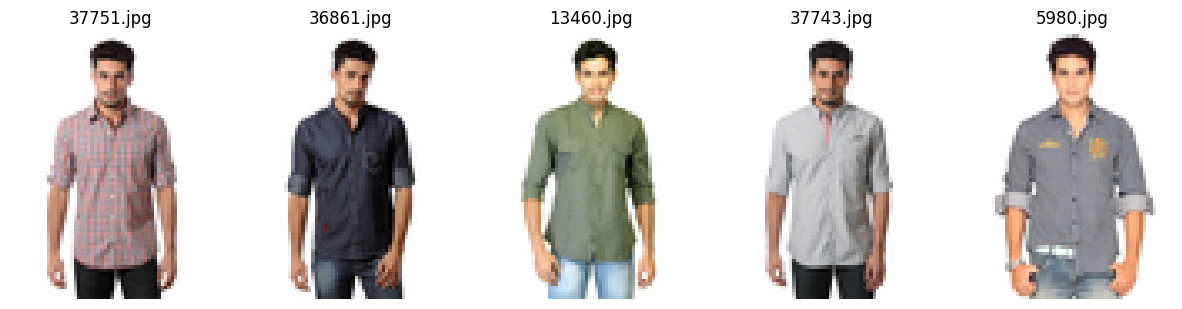

In [47]:
import os
from PIL import Image
import matplotlib.pyplot as plt

shirt_images_path = '/content/fashion_data/Shirts/'
shirt_files = [f for f in os.listdir(shirt_images_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f"Displaying {min(5, len(shirt_files))} example shirt images from the dataset:")

plt.figure(figsize=(15, 5))
for i, img_file in enumerate(shirt_files[:5]): # Display up to 5 images
    img_path = os.path.join(shirt_images_path, img_file)
    img = Image.open(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(img_file)
    plt.axis('off')
plt.show()

In [48]:
from PIL import Image
import torch
import torch.nn.functional as F

def analyze_prediction(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = F.softmax(outputs, dim=1)

    # Get top 5 predictions
    top_p, top_class = probabilities.topk(5, dim=1)

    print(f"\nTop 5 predictions for {image_path}:")
    for i in range(top_p.size(1)):
        idx = top_class.squeeze()[i].item()
        prob = top_p.squeeze()[i].item()
        predicted_category = classes[idx]
        print(f"- {predicted_category}: {prob:.4f}")

In [49]:
!pip install kaggle

In [52]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"nitishhansa","key":"2d4a5db2ae444f2d79880f23c6a482a0"}'}

In [53]:
print("Analyzing the uploaded image: shirt.jpg")

user_example_measurements = {"chest": 100, "waist": 88} # Example: User's actual measurements
user_example_brand = "Zara" # User usually wears this brand
target_example_brand = "H&M" # User wants to buy from this brand
item_example_condition = "Like-New" # Condition of the item for resale estimation

result = fashion_advisor(
    "shirt.jpg",
    user_measurements=user_example_measurements,
    user_current_brand=user_example_brand,
    target_brand=target_example_brand,
    item_condition=item_example_condition
)

print("\n🎯 FINAL RESULT FOR UPLOADED SHIRT:")
print(result)

Analyzing the uploaded image: shirt.jpg
👕 Predicted Category: Tshirts

🎯 FINAL RESULT FOR UPLOADED SHIRT:
{'predicted_category': 'Tshirts', 'recommended_size_for_target_brand': 'S', 'estimated_resale_value': 'Estimated resale value for a Like-New H&M tshirts: $12.96 - $15.84 (Tier: Mid-Range)', 'similar_item_recommendations': ['/content/fashion_data/Tshirts/5427.jpg', '/content/fashion_data/Tshirts/37620.jpg', '/content/fashion_data/Tshirts/2295.jpg', '/content/fashion_data/Tshirts/5818.jpg', '/content/fashion_data/Kurtas/7413.jpg']}


In [54]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!mkdir -p /content/drive/MyDrive/fashion_ai

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
fashion-product-images-small.zip: Skipping, found more recently modified local copy (use --force to force download)


In [56]:
!unzip -o fashion-product-images-small.zip

Streaming output truncated to the last 5000 lines.
  inflating: myntradataset/images/5813.jpg  
  inflating: myntradataset/images/58131.jpg  
  inflating: myntradataset/images/58132.jpg  
  inflating: myntradataset/images/58133.jpg  
  inflating: myntradataset/images/58135.jpg  
  inflating: myntradataset/images/58136.jpg  
  inflating: myntradataset/images/58137.jpg  
  inflating: myntradataset/images/58138.jpg  
  inflating: myntradataset/images/58139.jpg  
  inflating: myntradataset/images/5814.jpg  
  inflating: myntradataset/images/58140.jpg  
  inflating: myntradataset/images/58141.jpg  
  inflating: myntradataset/images/58143.jpg  
  inflating: myntradataset/images/58144.jpg  
  inflating: myntradataset/images/58145.jpg  
  inflating: myntradataset/images/58146.jpg  
  inflating: myntradataset/images/58147.jpg  
  inflating: myntradataset/images/58148.jpg  
  inflating: myntradataset/images/58149.jpg  
  inflating: myntradataset/images/5815.jpg  
  inflating: myntradataset/image

In [57]:
# 2. AI Fair Resale Value Estimator
baseline_retail_prices = {
    "Luxury": {
        "Gucci": {
            "shirt": 700,
            "jeans": 800,
            "dresses": 2500,
            "leather jacket": 4500,
            "handbags": 3000,
            "tshirts": 400
        }
    },
    "Mid-Range": {
        "Zara": {
            "shirt": 50,
            "jeans": 60,
            "dresses": 80,
            "leather jacket": 150,
            "tshirts": 30
        },
        "H&M": {
            "shirt": 30,
            "jeans": 40,
            "dresses": 60,
            "tshirts": 20
        }
    }
}

def estimate_resale_value(brand, category, condition):
    brand_lower = brand.lower().replace(" ", "").replace("-", "")
    category_lower = category.lower().replace(" ", "").replace("-", "")

    base_price = 0
    brand_tier = "Unknown"

    # Find base price and tier
    for tier, brands_in_tier in baseline_retail_prices.items():
        for b, items in brands_in_tier.items():
            if b.lower().replace(" ", "").replace("-", "") == brand_lower:
                brand_tier = tier
                if category_lower in [c.lower().replace(" ", "").replace("-", "") for c in items]:
                    # Normalize category key for lookup
                    category_key = next((c for c in items if c.lower().replace(" ", "").replace("-", "") == category_lower), category)
                    base_price = items[category_key]
                break
        if base_price > 0: # Found the brand and category
            break

    if base_price == 0:
        return f"Resale value estimation not available for {brand} {category}."

    # Depreciation multipliers
    depreciation_multipliers = {
        "Like-New": 0.8,
        "Good": 0.6,
        "Fair": 0.4,
        "Poor": 0.2
    }

    condition_multiplier = depreciation_multipliers.get(condition, 0.3) # Default to a conservative multiplier

    # Category-specific adjustments (e.g., leather jackets hold value better)
    category_adjustment = 1.0
    if "leather" in category_lower and "jacket" in category_lower:
        category_adjustment = 1.2
    elif "handbags" in category_lower:
        category_adjustment = 1.1
    elif "tshirt" in category_lower or "shirt" in category_lower:
        category_adjustment = 0.9

    estimated_value = base_price * condition_multiplier * category_adjustment

    # Generate a price range for realism (e.g., +/- 10%)
    min_price = estimated_value * 0.9
    max_price = estimated_value * 1.1

    return f"Estimated resale value for a {condition} {brand} {category}: ${min_price:.2f} - ${max_price:.2f} (Tier: {brand_tier})"

In [58]:
query = get_embedding("shirt.jpg").reshape(1, -1)

distances, indices = index.search(query, k=5)

print("Similar items:")
for i in indices[0]:
    print(image_paths[i])

Similar items:
/content/fashion_data/Tshirts/5427.jpg
/content/fashion_data/Tshirts/37620.jpg
/content/fashion_data/Tshirts/2295.jpg
/content/fashion_data/Tshirts/5818.jpg
/content/fashion_data/Kurtas/7413.jpg


Displaying similar item recommendations:


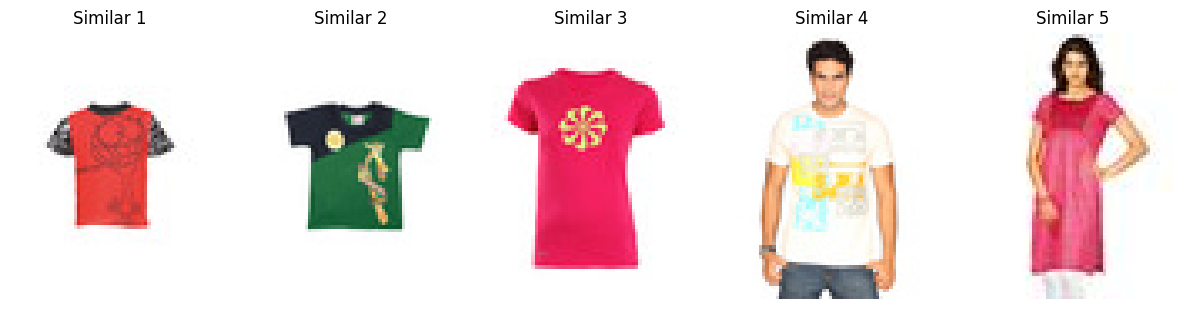

In [59]:
import matplotlib.pyplot as plt
from PIL import Image

# Assuming 'result' contains the last fashion_advisor output with similar_item_recommendations
if 'result' in globals() and 'similar_item_recommendations' in result:
    print("Displaying similar item recommendations:")
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(result['similar_item_recommendations']):
        try:
            img = Image.open(img_path)
            plt.subplot(1, 5, i + 1) # 1 row, 5 columns
            plt.imshow(img)
            plt.title(f"Similar {i+1}")
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
            continue
    plt.show()
else:
    print("No 'result' or 'similar_item_recommendations' found to display. Please run the fashion_advisor function first.")

In [60]:
print("Analyzing the top predictions for shirt.jpg:")
analyze_prediction("shirt.jpg")

Analyzing the top predictions for shirt.jpg:

Top 5 predictions for shirt.jpg:
- Tshirts: 0.6144
- Innerwear Vests: 0.3536
- Sweaters: 0.0067
- Tops: 0.0029
- Dresses: 0.0017


In [61]:
import faiss

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)

index.add(embeddings)

print("Total items indexed:", index.ntotal)

Total items indexed: 44419


In [62]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder("/content/fashion_data", transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [63]:
print(predict("shirt.jpg"))

133


In [64]:
import torch.nn as nn

feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [67]:
from google.colab import files
import os
import shutil

print("Preparing files for download...")

base_path_drive = "/content/drive/MyDrive/fashion_ai"

# Define the files to download
files_to_download = [
    "model.pth",
    "classes.pkl",
    "image_paths.pkl",
    "faiss.index"
]

# Create a local directory for downloads if it doesn't exist
local_download_dir = "./downloaded_artifacts"
os.makedirs(local_download_dir, exist_ok=True)

for filename in files_to_download:
    drive_path = os.path.join(base_path_drive, filename)
    local_path = os.path.join(local_download_dir, filename)

    if os.path.exists(drive_path):
        try:
            shutil.copyfile(drive_path, local_path)
            print(f"Copied {filename} to local directory.")
            files.download(local_path)
            print(f"Initiated download for {filename}.")
        except Exception as e:
            print(f"Error copying/downloading {filename}: {e}")
    else:
        print(f"File not found in Google Drive: {filename}")

print("Download process initiated for all specified files.")

Preparing files for download...
Copied model.pth to local directory.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Initiated download for model.pth.
Copied classes.pkl to local directory.


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Initiated download for image_paths.pkl.
Copied faiss.index to local directory.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Initiated download for faiss.index.
Download process initiated for all specified files.
